In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
"""
Q1: 
A retail store wants to identify customers who make frequent purchases. Given the dataset below, write a code to:
1.	Group customers by their IDs.
2.	Calculate the total number of purchases per customer.
3.	Identify the top 3 frequent customers.
Dataset:
data = {'Customer_ID': [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],
        'Purchase_Amount': [200, 150, 180, 220, 300, 200, 100, 400, 250, 300]}

Expected Output:

Total Purchases per Customer:
   Customer_ID  Purchase_Amount
0          101              520
1          102              600
2          103              480
3          104              300
4          105              400

Top 3 Frequent Customers:
   Customer_ID  Purchase_Amount
1          102              600
0          101              520
2          103              480
"""

"\nQ1: \nA retail store wants to identify customers who make frequent purchases. Given the dataset below, write a code to:\n1.\tGroup customers by their IDs.\n2.\tCalculate the total number of purchases per customer.\n3.\tIdentify the top 3 frequent customers.\nDataset:\ndata = {'Customer_ID': [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],\n        'Purchase_Amount': [200, 150, 180, 220, 300, 200, 100, 400, 250, 300]}\n\nExpected Output:\n\nTotal Purchases per Customer:\n   Customer_ID  Purchase_Amount\n0          101              520\n1          102              600\n2          103              480\n3          104              300\n4          105              400\n\nTop 3 Frequent Customers:\n   Customer_ID  Purchase_Amount\n1          102              600\n0          101              520\n2          103              480\n"

In [3]:
data = {
    "Customer_ID": [101, 102, 103, 101, 104, 102, 101, 105, 102, 103],
    "Purchase_Amount": [200, 150, 180, 220, 300, 200, 100, 400, 250, 300],
}
df = pd.DataFrame(data)
purchase_count = df.groupby(['Customer_ID'], as_index=False)['Purchase_Amount'].sum()
frequent_customer = purchase_count.sort_values(by='Purchase_Amount', ascending=False).head(3)
print("Total Purchase per customer :\n", purchase_count)
print("Top 3 Frequent Customers: \n", frequent_customer)

Total Purchase per customer :
    Customer_ID  Purchase_Amount
0          101              520
1          102              600
2          103              480
3          104              300
4          105              400
Top 3 Frequent Customers: 
    Customer_ID  Purchase_Amount
1          102              600
0          101              520
2          103              480


In [4]:
"""
Question 2:
A company tracks the daily sales of a product over a month. 
You are tasked with identifying any abnormal sales data using the IQR (Interquartile Range) method.
Dataset (Daily Sales in Units):

data = {'Day': range(1, 31),
        'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120,
                  33, 29, 27, 35, 40, 50, 85, 110, 105, 92,
                  30, 34, 31, 33, 36, 42, 44, 48, 90, 200]}

Tasks:
1. Calculate the Q1 (25th percentile) and Q3 (75th percentile).
2. Determine the IQR.
3. Identify the Lower Bound and Upper Bound.
4. Detect and display the outliers.
5. Replace the Outliers with the Median Value.
Expected Output:
Q1: 31.5, Q3: 83.75, IQR: 52.25
Lower Bound: -46.875, Upper Bound: 162.125
Outliers Detected:
    Day  Sales
29   30    200
Data After Replacing Outliers with Median:
    Day  Sales
0     1   25.0
1     2   30.0
2     3   28.0
3     4   45.0
4     5   55.0
5     6   60.0
....
29   30   43.0
"""

"\nQuestion 2:\nA company tracks the daily sales of a product over a month. \nYou are tasked with identifying any abnormal sales data using the IQR (Interquartile Range) method.\nDataset (Daily Sales in Units):\n\ndata = {'Day': range(1, 31),\n        'Sales': [25, 30, 28, 45, 55, 60, 22, 80, 95, 120,\n                  33, 29, 27, 35, 40, 50, 85, 110, 105, 92,\n                  30, 34, 31, 33, 36, 42, 44, 48, 90, 200]}\n\nTasks:\n1. Calculate the Q1 (25th percentile) and Q3 (75th percentile).\n2. Determine the IQR.\n3. Identify the Lower Bound and Upper Bound.\n4. Detect and display the outliers.\n5. Replace the Outliers with the Median Value.\nExpected Output:\nQ1: 31.5, Q3: 83.75, IQR: 52.25\nLower Bound: -46.875, Upper Bound: 162.125\nOutliers Detected:\n    Day  Sales\n29   30    200\nData After Replacing Outliers with Median:\n    Day  Sales\n0     1   25.0\n1     2   30.0\n2     3   28.0\n3     4   45.0\n4     5   55.0\n5     6   60.0\n....\n29   30   43.0\n"

In [26]:
data = {
    "Day": range(1, 31),
    "Sales": [
        25,
        30,
        28,
        45,
        55,
        60,
        22,
        80,
        95,
        120,
        33,
        29,
        27,
        35,
        40,
        50,
        85,
        110,
        105,
        92,
        30,
        34,
        31,
        33,
        36,
        42,
        44,
        48,
        90,
        200,
    ],
}
df = pd.DataFrame(data)

q1 = df.describe()["Sales"].loc["25%"]
q3 = df.describe()["Sales"].loc["75%"]
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
higher_bound = q3 + 1.5 * iqr

# replace outliers with median
outlier = df[(df["Sales"] < lower_bound) | (df["Sales"] > higher_bound)]

df.loc[outlier.index, "Sales"] = df["Sales"].median()

print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {higher_bound}")
print("Outliers Detected: \n", outlier)
print("After replacing outliers with median: \n", df)

Q1: 31.5, Q3: 83.75, IQR: 52.25
Lower Bound: -46.875, Upper Bound: 162.125
Outliers Detected: 
     Day  Sales
29   30    200
After replacing outliers with median: 
     Day  Sales
0     1     25
1     2     30
2     3     28
3     4     45
4     5     55
5     6     60
6     7     22
7     8     80
8     9     95
9    10    120
10   11     33
11   12     29
12   13     27
13   14     35
14   15     40
15   16     50
16   17     85
17   18    110
18   19    105
19   20     92
20   21     30
21   22     34
22   23     31
23   24     33
24   25     36
25   26     42
26   27     44
27   28     48
28   29     90
29   30     43


In [ ]:
"""
Question 3:

!A pharmaceutical company is testing the effectiveness of a new drug to reduce blood pressure. Two groups of patients were selected:
!Group 1 (Treatment): Received the drug
!Group 2 (Control): Received a placebo
? The company wants to check if there is a significant difference in the blood pressure levels
? between the two groups using an Independent T-Test.
Dataset:
data = {'Group': ['Treatment']*10 + ['Control']*10,
        'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,
                            130, 135, 140, 138, 142, 136, 139, 134, 137, 141]}
TODO Tasks:
1.	Perform an Independent T-Test.
2.	State the null and alternative hypotheses.
3.	Calculate the p-value.
4.	Conclude whether the drug has a significant effect.

Expected Output:
T-Statistic: -11.870553692962726
P-Value: 6.008066605173374e-10
Reject the Null Hypothesis: The drug has a significant effect
"""

"\nQuestion 3:\n\nA pharmaceutical company is testing the effectiveness of a new drug to reduce blood pressure. Two groups of patients were selected:\nGroup 1 (Treatment): Received the drug\nGroup 2 (Control): Received a placebo\nThe company wants to check if there is a significant difference in the blood pressure levels \nbetween the two groups using an Independent T-Test.\n\nDataset:\ndata = {'Group': ['Treatment']*10 + ['Control']*10,\n        'Blood_Pressure': [120, 115, 118, 123, 122, 119, 124, 117, 116, 121,\n                            130, 135, 140, 138, 142, 136, 139, 134, 137, 141]}\nTasks:\n1.\tPerform an Independent T-Test.\n2.\tState the null and alternative hypotheses.\n3.\tCalculate the p-value.\n4.\tConclude whether the drug has a significant effect.\nExpected Output:\nT-Statistic: -11.870553692962726\nP-Value: 6.008066605173374e-10\nReject the Null Hypothesis: The drug has a significant effect\n"

In [ ]:
data = {
    "Group": ["Treatment"] * 10 + ["Control"] * 10,
    "Blood_Pressure": [
        120,
        115,
        118,
        123,
        122,
        119,
        124,
        117,
        116,
        121,
        130,
        135,
        140,
        138,
        142,
        136,
        139,
        134,
        137,
        141,
    ],
}
df = pd.DataFrame(data)

from scipy.stats import ttest_ind

grp1 = df[df["Group"] == "Treatment"]["Blood_Pressure"]
grp2 = df[df["Group"] == "Control"]["Blood_Pressure"]

t_stat, p_value = ttest_ind(grp1, grp2)

print("T- Statistic: ", t_stat)
print("P-Value: ", p_value)

if p_value <0.05:
    print("Fail to reject null hypothesis: The drug has no effect")
else:
    print("Reject the Null Hypothesis: The drug has a significant effect")

T- Statistic:  -11.870553692962726
P-Value:  6.008066605173382e-10
Fail to reject null hypothesis: The drug has no effect


In [ ]:
"""
Question 4:
GlobalMart is a large retailer conducting advertisement campaigns in different regions.
The company spends money on two types of advertisements: TV Ads and Social Media Ads
They want to analyze how these ads influence their sales.

Your task is to calculate the Covariance and Correlation to determine which type of ad has a stronger impact on sales.
Tasks :
1.	Calculate the Covariance between ad budgets and sales to measure the direction of the relationship.
2.	Calculate the Correlation to measure the strength of the relationship.
3.	Determine which type of ad is more effective for increasing sales.


Expected Output:
Covariance (TV vs Sales): 3625.0
Covariance (Social Media vs Sales): 3225.0
Correlation (TV vs Sales): 0.9958640886279954
Correlation (Social Media vs Sales): 0.9724846021568381
TV Ads have a stronger impact on Sales.
"""

'\nQuestion 4:\nGlobalMart is a large retailer conducting advertisement campaigns in different regions. The company spends money on two types of advertisements: TV Ads and Social Media Ads\nThey want to analyze how these ads influence their sales.\nYour task is to calculate the Covariance and Correlation to determine which type of ad has a stronger impact on sales.\nTasks :\n1.\tCalculate the Covariance between ad budgets and sales to measure the direction of the relationship.\n2.\tCalculate the Correlation to measure the strength of the relationship.\n3.\tDetermine which type of ad is more effective for increasing sales.\n\n\nExpected Output:\nCovariance (TV vs Sales): 3625.0\nCovariance (Social Media vs Sales): 3225.0\nCorrelation (TV vs Sales): 0.9958640886279954\nCorrelation (Social Media vs Sales): 0.9724846021568381\nTV Ads have a stronger impact on Sales.\n'

In [34]:
data = {
    "Region": ["North", "South", "East", "West", "Central"],
    "TV_Ad_Budget": [200, 300, 400, 500, 600],
    "Social_Media_Budget": [150, 250, 300, 450, 500],
    "Sales": [20, 35, 50, 60, 80],
}
df = pd.DataFrame(data)
# TV Ad Budget
tv_sales_cov = df["TV_Ad_Budget"].cov(df["Sales"])
tv_sales_corr = df["TV_Ad_Budget"].corr(df["Sales"])

# Social Media Budget
sm_sales_cov = df["Social_Media_Budget"].cov(df["Sales"])
sm_sales_corr = df["Social_Media_Budget"].corr(df["Sales"])

print("Covariance (Tv vs Sales): ", tv_sales_cov)
print("Covariance (Social Media vs Sales): ", sm_sales_cov)
print("Correlation (Tv vs Sales): ", tv_sales_corr)
print("Correlation (Social Media vs Sales): ", sm_sales_corr)
if (tv_sales_cov + tv_sales_corr) > (sm_sales_cov + sm_sales_corr):
    print("TV Ads have stronger impact on sales")
else:
    print("Social Media Ads have stronger impact on sales")

Covariance (Tv vs Sales):  3625.0
Covariance (Social Media vs Sales):  3225.0
Correlation (Tv vs Sales):  0.9958640886279954
Correlation (Social Media vs Sales):  0.9724846021568381
TV Ads have stronger impact on sales


In [ ]:
"""
Question 5:
A company tracks the delivery time (in minutes) for its online orders. You are given the delivery times for 50 orders.
●	Calculate the mean and standard deviation of the delivery times.
●	Plot the Probability Density Function (PDF) to visualize the distribution.

Dataset (Delivery Times in Minutes):

[25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 27, 35, 40, 50, 85, 110, 105, 92, 30, 34, 31, 33, 36, 42, 44, 48, 90, 200, 20, 25, 27, 32, 38, 41, 47, 58, 62, 77, 80, 84, 90, 110, 123, 145, 150, 160]
You can try implementing this using libraries like numpy, matplotlib, and scipy
Expected Output:

Mean Delivery Time: 65.0625
Standard Deviation of Delivery Time: 41.718504212759115
"""

'\nQuestion 5:\nA company tracks the delivery time (in minutes) for its online orders. You are given the delivery times for 50 orders.\n●\tCalculate the mean and standard deviation of the delivery times.\n●\tPlot the Probability Density Function (PDF) to visualize the distribution.\nDataset (Delivery Times in Minutes):\n\n[25, 30, 28, 45, 55, 60, 22, 80, 95, 120, 33, 29, 27, 35, 40, 50, 85, 110, 105, 92, 30, 34, 31, 33, 36, 42, 44, 48, 90, 200, 20, 25, 27, 32, 38, 41, 47, 58, 62, 77, 80, 84, 90, 110, 123, 145, 150, 160]\nYou can try implementing this using libraries like numpy, matplotlib, and scipy\nExpected Output:\n\nMean Delivery Time: 65.0625\nStandard Deviation of Delivery Time: 41.718504212759115\n'

Mean Delivery Time:  [65.0625]
Standard Deviation of Delivery Time : [42.15998216]


Text(0.5, 1.0, 'Probability Density Function (PDF)')

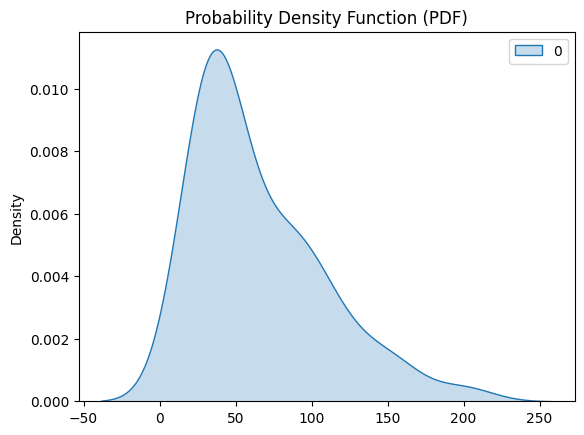

In [51]:
import seaborn as sns

data = [25, 30, 28, 45, 55, 60, 22, 80, 95,
         120, 33, 29, 27, 35, 40, 50, 85, 110, 
         105, 92, 30, 34, 31, 33, 36, 42, 44, 
         48, 90, 200, 20, 25, 27, 32, 38, 41, 
         47, 58, 62, 77, 80, 84, 90, 110, 123, 
         145, 150, 160]

delivery_time = pd.DataFrame(data)

mean = delivery_time.mean().values
std = delivery_time.std().values

print("Mean Delivery Time: ", mean)
print("Standard Deviation of Delivery Time :", std)

sns.kdeplot(delivery_time, fill=True)
plt.title("Probability Density Function (PDF)")